# Notebook 1 — Pre-processed PhysioNet PTB Beats
**Dataset:** `madhulikavikraman16/preprocessedzip` — `PTB_1_STFT_files/`  
Each `.npy` file = one isolated heartbeat waveform (150 timesteps, 1 lead), labelled `control` or `MI`.  
**Task:** Binary classification — Healthy (0) vs. Myocardial Infarction (1)  
**Models:** LTC (proper Hasani 2021) · CTRNN · Neural ODE (RK4) · CT-GRU  
**Metrics:** 12 per model


In [1]:
import os, glob, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, average_precision_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [2]:
# ─── CONFIG ────────────────────────────────────────────────────────────────
DATA_DIR   = "/kaggle/input/datasets/madhulikavikraman16/preprocessedzip/PTB_1_STFT_files"
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3
HIDDEN     = 64
SEED       = 42
SEQ_LEN    = 150   # fixed beat length (samples)
INPUT_SIZE = 1     # single-lead scalar per timestep

torch.manual_seed(SEED)
np.random.seed(SEED)


In [3]:
# ─── DATASET ────────────────────────────────────────────────────────────────
class PTBBeatDataset(Dataset):
    def __init__(self, file_list):
        self.files, self.labels, self.subject_ids = [], [], []
        for f in file_list:
            parts = os.path.basename(f).replace(".npy","").split("_")
            self.files.append(f)
            self.subject_ids.append(parts[1])
            self.labels.append(0 if parts[-1] == "control" else 1)

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        beat  = torch.tensor(np.load(self.files[idx]),
                             dtype=torch.float32).unsqueeze(-1)   # (150,1)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return beat, label


def build_loaders(data_dir, batch_size, seed=42):
    all_files = sorted(glob.glob(os.path.join(data_dir, "STFT_*.npy")))
    print(f"Total beat files: {len(all_files)}")

    subj2lbl = {}
    for f in all_files:
        p = os.path.basename(f).replace(".npy","").split("_")
        subj2lbl[p[1]] = 0 if p[-1] == "control" else 1

    subjects = list(subj2lbl.keys())
    lbls     = [subj2lbl[s] for s in subjects]
    tr_s, te_s = train_test_split(subjects, test_size=0.2,
                                   stratify=lbls, random_state=seed)
    tr_set, te_set = set(tr_s), set(te_s)

    train_files = [f for f in all_files
                   if os.path.basename(f).split("_")[1] in tr_set]
    test_files  = [f for f in all_files
                   if os.path.basename(f).split("_")[1] in te_set]
    print(f"Train beats: {len(train_files)} | Test beats: {len(test_files)}")

    n_pos = sum(1 for f in train_files
                if os.path.basename(f).replace(".npy","").split("_")[-1] != "control")
    n_neg = len(train_files) - n_pos
    pos_w = torch.tensor([n_neg / (n_pos + 1e-8)],
                         dtype=torch.float32).to(DEVICE)
    print(f"pos_weight: {pos_w.item():.3f}  (n_neg={n_neg}, n_pos={n_pos})")

    tr_loader = DataLoader(PTBBeatDataset(train_files),
                           batch_size=batch_size, shuffle=True)
    te_loader = DataLoader(PTBBeatDataset(test_files),
                           batch_size=batch_size, shuffle=False)
    return tr_loader, te_loader, pos_w


train_loader, test_loader, pos_weight = build_loaders(DATA_DIR, BATCH_SIZE, SEED)


Total beat files: 4862
Train beats: 3843 | Test beats: 1019
pos_weight: 0.254  (n_neg=778, n_pos=3065)


In [4]:
# ─── 12-METRIC EVALUATOR ────────────────────────────────────────────────────
def compute_12_metrics(labels, preds, probs):
    """
    Returns dict with 12 metrics given ground-truth labels, binary preds and
    raw probabilities.
    """
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    sens  = tp / (tp + fn + 1e-8)          # Sensitivity / Recall
    spec  = tn / (tn + fp + 1e-8)          # Specificity
    prec  = tp / (tp + fp + 1e-8)          # Precision / PPV
    npv   = tn / (tn + fn + 1e-8)          # Negative Predictive Value
    f1    = 2*prec*sens / (prec + sens + 1e-8)
    f2    = 5*prec*sens / (4*prec + sens + 1e-8)
    acc   = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    bal   = (sens + spec) / 2              # Balanced accuracy
    mcc   = matthews_corrcoef(labels, preds)
    kappa = cohen_kappa_score(labels, preds)
    auc   = roc_auc_score(labels, probs)
    ap    = average_precision_score(labels, probs)  # PR-AUC

    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, NPV=npv, F1=f1, F2=f2,
                BalancedAcc=bal, MCC=mcc, Kappa=kappa,
                ROC_AUC=auc, PR_AUC=ap)


def print_metrics(metrics: dict, model_name: str):
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        print(f"  {k:<18}: {v:.4f}")


In [5]:
# ─── TRAINING / EVAL HELPERS ────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy().astype(int))
    return all_labels, all_preds, all_probs


def run_training(model, model_name, train_loader, test_loader,
                 criterion, epochs=EPOCHS, patience=7):
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    best_auc, best_state, wait = 0.0, None, 0
    for epoch in range(1, epochs+1):
        loss = train_epoch(model, train_loader, optimizer, criterion)
        lbls, preds, probs = evaluate(model, test_loader)
        auc  = roc_auc_score(lbls, probs)
        scheduler.step()
        print(f"Epoch {epoch:3d}/{epochs} | Loss: {loss:.4f} | AUC: {auc:.4f}")
        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
            print(f"  ✓ Best AUC: {best_auc:.4f}")
        else:
            wait += 1
            if wait >= patience:
                print("  Early stopping.")
                break

    model.load_state_dict(best_state)
    lbls, preds, probs = evaluate(model, test_loader)
    metrics = compute_12_metrics(lbls, preds, probs)
    print_metrics(metrics, model_name)
    return metrics, lbls, preds, probs


In [6]:
# ─── CONFUSION MATRIX PLOT ──────────────────────────────────────────────────
def plot_cm(labels, preds, title, fname=None):
    cm = confusion_matrix(labels, preds, labels=[0,1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.xticks([0.5, 1.5], ["Negative (Healthy)", "Positive (MI)"])
    plt.yticks([0.5, 1.5], ["Negative (Healthy)", "Positive (MI)"], rotation=0)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    return cm


## Model 1 — Proper LTC (Hasani et al. 2021)

In [7]:
# ─── PROPER LTC CELL ────────────────────────────────────────────────────────
# τ(x,v) = τ_min + softplus(A·x_agg + B·v + b)
# Euler integration: v ← v + dt·(v_inf − v)·|cm|/τ
class LTCCell(nn.Module):
    def __init__(self, input_size, hidden_size, ode_steps=6):
        super().__init__()
        self.hidden_size = hidden_size
        self.ode_steps   = ode_steps
        self.register_buffer('dt', torch.tensor(1.0 / ode_steps))

        # Sensory synapses (input → hidden)
        self.sensory_W     = nn.Parameter(torch.rand(input_size, hidden_size)*0.5)
        self.sensory_erev  = nn.Parameter(
            (torch.randint(0,2,(input_size,hidden_size)).float()*2-1))
        self.sensory_mu    = nn.Parameter(torch.rand(input_size, hidden_size)*0.5+0.3)
        self.sensory_sigma = nn.Parameter(torch.rand(input_size, hidden_size)*5.0+3.0)

        # Recurrent synapses (hidden → hidden)
        self.W     = nn.Parameter(torch.rand(hidden_size, hidden_size)*0.5)
        self.erev  = nn.Parameter(
            (torch.randint(0,2,(hidden_size,hidden_size)).float()*2-1))
        self.mu    = nn.Parameter(torch.rand(hidden_size, hidden_size)*0.5+0.3)
        self.sigma = nn.Parameter(torch.rand(hidden_size, hidden_size)*5.0+3.0)

        # Membrane / leak
        self.vleak = nn.Parameter(torch.zeros(hidden_size))
        self.gleak = nn.Parameter(torch.ones(hidden_size))
        self.cm    = nn.Parameter(torch.ones(hidden_size)*0.5)

        # Liquid time-constant
        self.tau_min = nn.Parameter(torch.ones(hidden_size)*0.1)
        self.A_tau   = nn.Parameter(torch.randn(hidden_size)*0.1)
        self.B_tau   = nn.Parameter(torch.randn(hidden_size)*0.1)
        self.b_tau   = nn.Parameter(torch.zeros(hidden_size))

    def _sig(self, x, sigma): return torch.sigmoid(sigma * x)

    def forward(self, x, v):
        x_exp  = x.unsqueeze(2)
        s_gate = self._sig(x_exp - self.sensory_mu, self.sensory_sigma)
        s_num  = (torch.abs(self.sensory_W) * s_gate * self.sensory_erev).sum(1)
        s_den  = (torch.abs(self.sensory_W) * s_gate).sum(1)
        x_agg  = x.mean(dim=1, keepdim=True)

        v_t = v
        for _ in range(self.ode_steps):
            v_exp  = v_t.unsqueeze(2)
            r_gate = self._sig(v_exp - self.mu, self.sigma)
            r_num  = (torch.abs(self.W) * r_gate * self.erev).sum(1)
            r_den  = (torch.abs(self.W) * r_gate).sum(1)

            tot_num = self.gleak * self.vleak + r_num + s_num
            tot_den = self.gleak + r_den + s_den
            v_inf   = tot_num / (tot_den + 1e-8)

            tau = torch.abs(self.tau_min) + torch.nn.functional.softplus(
                self.A_tau * x_agg + self.B_tau * v_t + self.b_tau)
            dv  = (v_inf - v_t) * (torch.abs(self.cm) / (tau + 1e-8))
            v_t = v_t + self.dt * dv
        return v_t

    def clip_parameters(self):
        with torch.no_grad():
            self.cm.clamp_(1e-4, 100.0)
            self.gleak.clamp_(1e-5, 100.0)
            self.tau_min.clamp_(1e-4, 10.0)


class LTCClassifier(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN,
                 ode_steps=6, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = LTCCell(input_size, hidden_size, ode_steps)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        v = torch.zeros(x.shape[0], self.hidden_size, device=x.device)
        for t in range(x.shape[1]):
            v = self.cell(x[:, t, :], v)
        return self.fc(self.dropout(v)).squeeze(-1)   # raw logits

    def clip_parameters(self): self.cell.clip_parameters()


criterion_ltc = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
ltc_model = LTCClassifier().to(DEVICE)
print(f"LTC params: {sum(p.numel() for p in ltc_model.parameters() if p.requires_grad):,}")


LTC params: 17,153


In [8]:
# ─── CUSTOM TRAIN LOOP FOR LTC (clips parameters after each step) ───────────
def run_ltc_training(model, model_name, train_loader, test_loader, criterion,
                     epochs=EPOCHS, patience=7):
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    best_auc, best_state, wait = 0.0, None, 0
    for epoch in range(1, epochs+1):
        model.train()
        total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            model.clip_parameters()   # keep biophysical params in valid range
            total += loss.item()
        loss_avg = total / len(train_loader)
        lbls, preds, probs = evaluate(model, test_loader)
        auc = roc_auc_score(lbls, probs)
        scheduler.step()
        print(f"Epoch {epoch:3d}/{epochs} | Loss: {loss_avg:.4f} | AUC: {auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0; print(f"  ✓ Best AUC: {best_auc:.4f}")
        else:
            wait += 1
            if wait >= patience: print("  Early stopping."); break

    model.load_state_dict(best_state)
    lbls, preds, probs = evaluate(model, test_loader)
    metrics = compute_12_metrics(lbls, preds, probs)
    print_metrics(metrics, model_name)
    return metrics, lbls, preds, probs


ltc_metrics, ltc_lbls, ltc_preds, ltc_probs = run_ltc_training(
    ltc_model, "LTC — Pre-processed PTB", train_loader, test_loader, criterion_ltc)


Epoch   1/30 | Loss: 0.2811 | AUC: 0.5723
  ✓ Best AUC: 0.5723
Epoch   2/30 | Loss: 0.2802 | AUC: 0.6371
  ✓ Best AUC: 0.6371
Epoch   3/30 | Loss: 0.2813 | AUC: 0.6176
Epoch   4/30 | Loss: 0.2812 | AUC: 0.6083
Epoch   5/30 | Loss: 0.2810 | AUC: 0.6017
Epoch   6/30 | Loss: 0.2808 | AUC: 0.6117
Epoch   7/30 | Loss: 0.2789 | AUC: 0.6450
  ✓ Best AUC: 0.6450
Epoch   8/30 | Loss: 0.2791 | AUC: 0.6316
Epoch   9/30 | Loss: 0.2809 | AUC: 0.6355
Epoch  10/30 | Loss: 0.2779 | AUC: 0.6316
Epoch  11/30 | Loss: 0.2785 | AUC: 0.6335
Epoch  12/30 | Loss: 0.2782 | AUC: 0.6347
Epoch  13/30 | Loss: 0.2784 | AUC: 0.6390
Epoch  14/30 | Loss: 0.2750 | AUC: 0.6326
  Early stopping.

  LTC — Pre-processed PTB
  Accuracy          : 0.7723
  Sensitivity       : 0.8884
  Specificity       : 0.1000
  Precision         : 0.8512
  NPV               : 0.1339
  F1                : 0.8694
  F2                : 0.8807
  BalancedAcc       : 0.4942
  MCC               : -0.0132
  Kappa             : -0.0130
  ROC_AUC   

## Model 2 — CTRNN (Continuous-Time RNN)

In [9]:
# dh/dt = -h/τ + tanh(W_in·x + W_rec·h + b)   (Euler, τ via softplus)
class CTRNNClassifier(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN,
                 ode_steps=3, dt=0.1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.ode_steps   = ode_steps
        self.dt          = dt
        self.W_in  = nn.Linear(input_size, hidden_size, bias=False)
        self.W_rec = nn.Linear(hidden_size, hidden_size)
        self._tau  = nn.Parameter(torch.ones(hidden_size))
        self.drop  = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden_size, 1)

    @property
    def tau(self):
        return nn.functional.softplus(self._tau) + 1e-4

    def forward(self, x):
        h = torch.zeros(x.shape[0], self.hidden_size, device=x.device)
        for t in range(x.shape[1]):
            xt = x[:, t, :]
            for _ in range(self.ode_steps):
                dhdt = (-h / self.tau +
                        torch.tanh(self.W_in(xt) + self.W_rec(h)))
                h = h + self.dt * dhdt
        return self.fc(self.drop(h)).squeeze(-1)   # raw logits


criterion_ctrnn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
ctrnn_model     = CTRNNClassifier().to(DEVICE)
print(f"CTRNN params: {sum(p.numel() for p in ctrnn_model.parameters() if p.requires_grad):,}")

ctrnn_metrics, ctrnn_lbls, ctrnn_preds, ctrnn_probs = run_training(
    ctrnn_model, "CTRNN — Pre-processed PTB",
    train_loader, test_loader, criterion_ctrnn)


CTRNN params: 4,353
Epoch   1/30 | Loss: 0.2693 | AUC: 0.6168
  ✓ Best AUC: 0.6168
Epoch   2/30 | Loss: 0.2562 | AUC: 0.6954
  ✓ Best AUC: 0.6954
Epoch   3/30 | Loss: 0.2434 | AUC: 0.7158
  ✓ Best AUC: 0.7158
Epoch   4/30 | Loss: 0.2430 | AUC: 0.7061
Epoch   5/30 | Loss: 0.2397 | AUC: 0.7278
  ✓ Best AUC: 0.7278
Epoch   6/30 | Loss: 0.2467 | AUC: 0.7279
  ✓ Best AUC: 0.7279
Epoch   7/30 | Loss: 0.2320 | AUC: 0.7381
  ✓ Best AUC: 0.7381
Epoch   8/30 | Loss: 0.2314 | AUC: 0.7407
  ✓ Best AUC: 0.7407
Epoch   9/30 | Loss: 0.2275 | AUC: 0.6638
Epoch  10/30 | Loss: 0.2256 | AUC: 0.7767
  ✓ Best AUC: 0.7767
Epoch  11/30 | Loss: 0.2231 | AUC: 0.7952
  ✓ Best AUC: 0.7952
Epoch  12/30 | Loss: 0.2202 | AUC: 0.7410
Epoch  13/30 | Loss: 0.2164 | AUC: 0.7551
Epoch  14/30 | Loss: 0.2157 | AUC: 0.6528
Epoch  15/30 | Loss: 0.2170 | AUC: 0.7579
Epoch  16/30 | Loss: 0.2103 | AUC: 0.7651
Epoch  17/30 | Loss: 0.2101 | AUC: 0.7891
Epoch  18/30 | Loss: 0.2062 | AUC: 0.7701
  Early stopping.

  CTRNN — Pre-pr

## Model 3 — Neural ODE (RK4 integration)

In [10]:
# f(x, h) = tanh([x; h] · W + b)   — RK4 per timestep
class NODEClassifier(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN,
                 ode_steps=2, dt=0.1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.ode_steps   = ode_steps
        self.dt          = dt
        self.W   = nn.Linear(input_size + hidden_size, hidden_size)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def _f(self, x, h):
        return torch.tanh(self.W(torch.cat([x, h], dim=-1)))

    def forward(self, x):
        h = torch.zeros(x.shape[0], self.hidden_size, device=x.device)
        dt = self.dt
        for t in range(x.shape[1]):
            xt = x[:, t, :]
            for _ in range(self.ode_steps):
                k1 = dt * self._f(xt, h)
                k2 = dt * self._f(xt, h + 0.5*k1)
                k3 = dt * self._f(xt, h + 0.5*k2)
                k4 = dt * self._f(xt, h + k3)
                h  = h + (k1 + 2*k2 + 2*k3 + k4) / 6.0
        return self.fc(self.drop(h)).squeeze(-1)   # raw logits


criterion_node = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
node_model     = NODEClassifier().to(DEVICE)
print(f"NODE params: {sum(p.numel() for p in node_model.parameters() if p.requires_grad):,}")

node_metrics, node_lbls, node_preds, node_probs = run_training(
    node_model, "Neural ODE — Pre-processed PTB",
    train_loader, test_loader, criterion_node)


NODE params: 4,289
Epoch   1/30 | Loss: 1.2198 | AUC: 0.6657
  ✓ Best AUC: 0.6657
Epoch   2/30 | Loss: 0.5459 | AUC: 0.6658
  ✓ Best AUC: 0.6658
Epoch   3/30 | Loss: 0.3219 | AUC: 0.6677
  ✓ Best AUC: 0.6677
Epoch   4/30 | Loss: 0.2949 | AUC: 0.6678
  ✓ Best AUC: 0.6678
Epoch   5/30 | Loss: 0.2815 | AUC: 0.6682
  ✓ Best AUC: 0.6682
Epoch   6/30 | Loss: 0.2712 | AUC: 0.6683
  ✓ Best AUC: 0.6683
Epoch   7/30 | Loss: 0.2666 | AUC: 0.6687
  ✓ Best AUC: 0.6687
Epoch   8/30 | Loss: 0.2703 | AUC: 0.6699
  ✓ Best AUC: 0.6699
Epoch   9/30 | Loss: 0.2654 | AUC: 0.6690
Epoch  10/30 | Loss: 0.2618 | AUC: 0.6704
  ✓ Best AUC: 0.6704
Epoch  11/30 | Loss: 0.2666 | AUC: 0.6711
  ✓ Best AUC: 0.6711
Epoch  12/30 | Loss: 0.2680 | AUC: 0.6709
Epoch  13/30 | Loss: 0.2580 | AUC: 0.6692
Epoch  14/30 | Loss: 0.2541 | AUC: 0.6700
Epoch  15/30 | Loss: 0.2589 | AUC: 0.6706
Epoch  16/30 | Loss: 0.2627 | AUC: 0.6694
Epoch  17/30 | Loss: 0.2569 | AUC: 0.6679
Epoch  18/30 | Loss: 0.2519 | AUC: 0.6699
  Early stoppin

## Model 4 — CT-GRU (Mozer et al. 2017)

In [11]:
# Multi-scale memory traces with log-linear time constants
class CTGRUClassifier(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN, M=4, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.M           = M

        ln_tau = np.array([np.log(10.0**(0.5*i)) for i in range(M)], dtype=np.float32)
        self.register_buffer('ln_tau', torch.tensor(ln_tau).view(1,1,M))
        self.register_buffer('decay',
            torch.tensor(np.exp(-1.0/np.exp(ln_tau)).astype(np.float32)).view(1,1,M))

        fused = input_size + hidden_size
        mid   = float(np.log(np.sqrt(np.exp(0) * np.exp((M-1)*0.5*np.log(10)))))

        self.W_r = nn.Linear(fused, hidden_size*M);  nn.init.constant_(self.W_r.bias, mid)
        self.W_q = nn.Linear(fused, hidden_size)
        self.W_s = nn.Linear(fused, hidden_size*M);  nn.init.constant_(self.W_s.bias, mid)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        B, T, _ = x.size()
        H, M    = self.hidden_size, self.M
        h_hat   = torch.zeros(B, H, M, device=x.device)

        for t in range(T):
            xt    = x[:, t, :]
            h     = h_hat.sum(dim=2)                          # (B, H)
            fused = torch.cat([xt, h], dim=-1)

            # 1 — Retrieval
            ln_r = self.W_r(fused).view(B, H, M)
            r_ki = torch.softmax(-(ln_r - self.ln_tau)**2, dim=2)

            # 2 — Event detection (retrieve + detect new event)
            retr = (r_ki * h_hat).sum(dim=2)
            q_k  = torch.tanh(self.W_q(torch.cat([xt, retr], dim=-1))).unsqueeze(2)

            # 3 — Storage
            ln_s = self.W_s(fused).view(B, H, M)
            s_ki = torch.softmax(-(ln_s - self.ln_tau)**2, dim=2)

            # 4 — Update with exponential decay
            h_hat = ((1.0 - s_ki) * h_hat + s_ki * q_k) * self.decay

        return self.fc(self.drop(h_hat.sum(dim=2))).squeeze(-1)   # raw logits


criterion_ctgru = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
ctgru_model     = CTGRUClassifier().to(DEVICE)
print(f"CT-GRU params: {sum(p.numel() for p in ctgru_model.parameters() if p.requires_grad):,}")

ctgru_metrics, ctgru_lbls, ctgru_preds, ctgru_probs = run_training(
    ctgru_model, "CT-GRU — Pre-processed PTB",
    train_loader, test_loader, criterion_ctgru)


CT-GRU params: 38,081
Epoch   1/30 | Loss: 0.2792 | AUC: 0.5765
  ✓ Best AUC: 0.5765
Epoch   2/30 | Loss: 0.2718 | AUC: 0.6220
  ✓ Best AUC: 0.6220
Epoch   3/30 | Loss: 0.2624 | AUC: 0.6388
  ✓ Best AUC: 0.6388
Epoch   4/30 | Loss: 0.2531 | AUC: 0.6642
  ✓ Best AUC: 0.6642
Epoch   5/30 | Loss: 0.2461 | AUC: 0.6414
Epoch   6/30 | Loss: 0.2454 | AUC: 0.6558
Epoch   7/30 | Loss: 0.2375 | AUC: 0.6771
  ✓ Best AUC: 0.6771
Epoch   8/30 | Loss: 0.2340 | AUC: 0.6616
Epoch   9/30 | Loss: 0.2380 | AUC: 0.6613
Epoch  10/30 | Loss: 0.2445 | AUC: 0.6712
Epoch  11/30 | Loss: 0.2327 | AUC: 0.6813
  ✓ Best AUC: 0.6813
Epoch  12/30 | Loss: 0.2335 | AUC: 0.6779
Epoch  13/30 | Loss: 0.2318 | AUC: 0.6940
  ✓ Best AUC: 0.6940
Epoch  14/30 | Loss: 0.2281 | AUC: 0.6891
Epoch  15/30 | Loss: 0.2267 | AUC: 0.6856
Epoch  16/30 | Loss: 0.2224 | AUC: 0.7305
  ✓ Best AUC: 0.7305
Epoch  17/30 | Loss: 0.2240 | AUC: 0.7039
Epoch  18/30 | Loss: 0.2201 | AUC: 0.7399
  ✓ Best AUC: 0.7399
Epoch  19/30 | Loss: 0.2185 | AUC

## Confusion Matrices (all 4 models)

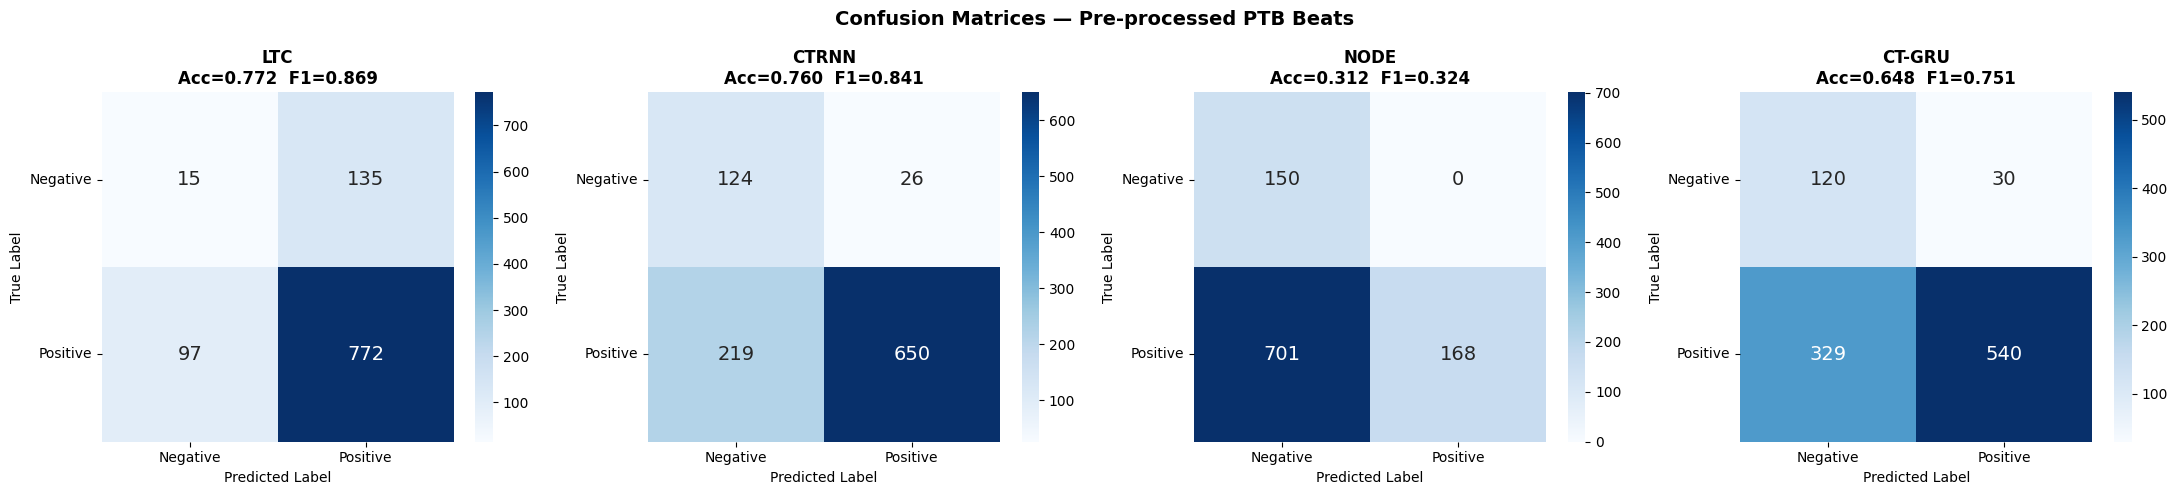

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Confusion Matrices — Pre-processed PTB Beats", fontsize=14, fontweight='bold')

results_all = [
    ("LTC",      ltc_lbls,   ltc_preds),
    ("CTRNN",    ctrnn_lbls, ctrnn_preds),
    ("NODE",     node_lbls,  node_preds),
    ("CT-GRU",   ctgru_lbls, ctgru_preds),
]

for ax, (name, lbls, preds) in zip(axes, results_all):
    cm = confusion_matrix(lbls, preds, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    acc  = (tn+tp)/(tn+fp+fn+tp+1e-8)
    f1   = 2*tp/(2*tp+fp+fn+1e-8)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                ax=ax, annot_kws={"size":14})
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_title(f"{name}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=12, fontweight='bold')
    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(["Negative","Positive"])
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(["Negative","Positive"], rotation=0)

plt.tight_layout()
plt.savefig("cm_preprocessed_all.png", dpi=150, bbox_inches='tight')
plt.show()


## Summary Table — All 12 Metrics

In [13]:
import pandas as pd

summary = pd.DataFrame({
    "LTC":    ltc_metrics,
    "CTRNN":  ctrnn_metrics,
    "NODE":   node_metrics,
    "CT-GRU": ctgru_metrics,
}).T.round(4)

print("\n=== 12-Metric Summary — Pre-processed PTB Beats ===")
print(summary.to_string())
summary



=== 12-Metric Summary — Pre-processed PTB Beats ===
        Accuracy  Sensitivity  Specificity  Precision     NPV      F1      F2  BalancedAcc     MCC   Kappa  ROC_AUC  PR_AUC
LTC       0.7723       0.8884       0.1000     0.8512  0.1339  0.8694  0.8807       0.4942 -0.0132 -0.0130   0.6450  0.9206
CTRNN     0.7596       0.7480       0.8267     0.9615  0.3615  0.8414  0.7828       0.7873  0.4309  0.3750   0.7952  0.9512
NODE      0.3121       0.1933       1.0000     1.0000  0.1763  0.3240  0.2305       0.5967  0.1846  0.0659   0.6711  0.9320
CT-GRU    0.6477       0.6214       0.8000     0.9474  0.2673  0.7505  0.6673       0.7107  0.3007  0.2310   0.7638  0.9500


,Accuracy,Sensitivity,Specificity,Precision,NPV,F1,F2,BalancedAcc,MCC,Kappa,ROC_AUC,PR_AUC
LTC,0.7723,0.8884,0.1000,0.8512,0.1339,0.8694,0.8807,0.4942,-0.0132,-0.0130,0.6450,0.9206
CTRNN,0.7596,0.7480,0.8267,0.9615,0.3615,0.8414,0.7828,0.7873,0.4309,0.3750,0.7952,0.9512
NODE,0.3121,0.1933,1.0000,1.0000,0.1763,0.3240,0.2305,0.5967,0.1846,0.0659,0.6711,0.9320
CT-GRU,0.6477,0.6214,0.8000,0.9474,0.2673,0.7505,0.6673,0.7107,0.3007,0.2310,0.7638,0.9500
